<a href="https://colab.research.google.com/github/emilsar/Cedars/blob/main/Introduction_e.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Import libraries

In [ ]:
!pip install segmentation_models_pytorch
!git clone https://github.com/emilsar/Cedars.git
%cd Cedars/Project3

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.8/154.8 kB 3.8 MB/s eta 0:00:00
Cloning into 'Cedars'...
remote: Enumerating objects: 1354, done.
remote: Counting objects: 100% (97/97), done.
remote: Compressing objects: 100% (92/92), done.
remote: Total 1354 (delta 58), reused 4 (delta 4), pack-reused 1257 (from 3)
Receiving objects: 100% (1354/1354), 1.24 GiB | 31.64 MiB/s, done.
Resolving deltas: 100% (538/538), done.
Updating files: 100% (900/900), done.
/content/Cedars/Project3


In [ ]:
from matplotlib import pyplot as plt
import numpy as np
from scipy.stats import spearmanr
import pandas as pd
import torch, cv2, glob, tqdm, os, copy
from sklearn.model_selection import train_test_split
from scipy import ndimage
from skimage import measure, color, io
from skimage.io import imread
import segmentation_models_pytorch as smp
from PIL import Image
from sklearn.utils.class_weight import compute_class_weight
#Pytorch
from torch.utils.data import TensorDataset, DataLoader
import torch.nn as nn


# Load Data

In [ ]:
# Load data (already float32, channels-first)
x_files = sorted(glob.glob("imagedata/X/*.npy"))
y_files = sorted(glob.glob("imagedata/y/*.npy"))

X = np.stack([np.load(f) for f in x_files], axis=0)  # (N, 3, 256, 256), float32 [0,1]
y = np.stack([np.load(f) for f in y_files], axis=0)  # (N, 256, 256), int

print(f"Loaded X: {X.shape}, {X.dtype}, range [{X.min():.3f}, {X.max():.3f}]")
print(f"Loaded y: {y.shape}, {y.dtype}, unique labels: {np.unique(y)}")


Loaded X: (200, 3, 256, 256), float32, range [0.000, 1.000]
Loaded y: (200, 256, 256), int64, unique labels: [0 1 2]
After filtering: 191 images

Final shapes:
X_train: torch.Size([121, 3, 256, 256]), dtype: torch.float32
Y_train: torch.Size([121, 256, 256]), dtype: torch.int64
X_val: torch.Size([31, 3, 256, 256])
X_test: torch.Size([39, 3, 256, 256])


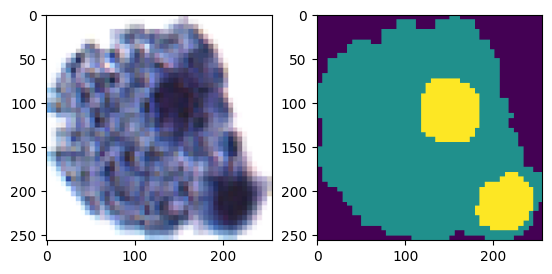

In [ ]:
plt.subplot(1,2,1)
plt.imshow(images[7])
plt.subplot(1,2,2)
plt.imshow(labels[7])